<a href="https://colab.research.google.com/github/darrickpang/Email/blob/master/Face_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install mediapipe

import cv2
import mediapipe as mp

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


In [2]:
# Load Mediapipe face detector
mp_face = mp.solutions.face_detection
face_detection = mp_face.FaceDetection(model_selection=0, min_detection_confidence=0.5)

In [5]:
# Load image
image = cv2.imread("image.jpg")
rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Detect faces
results = face_detection.process(rgb)

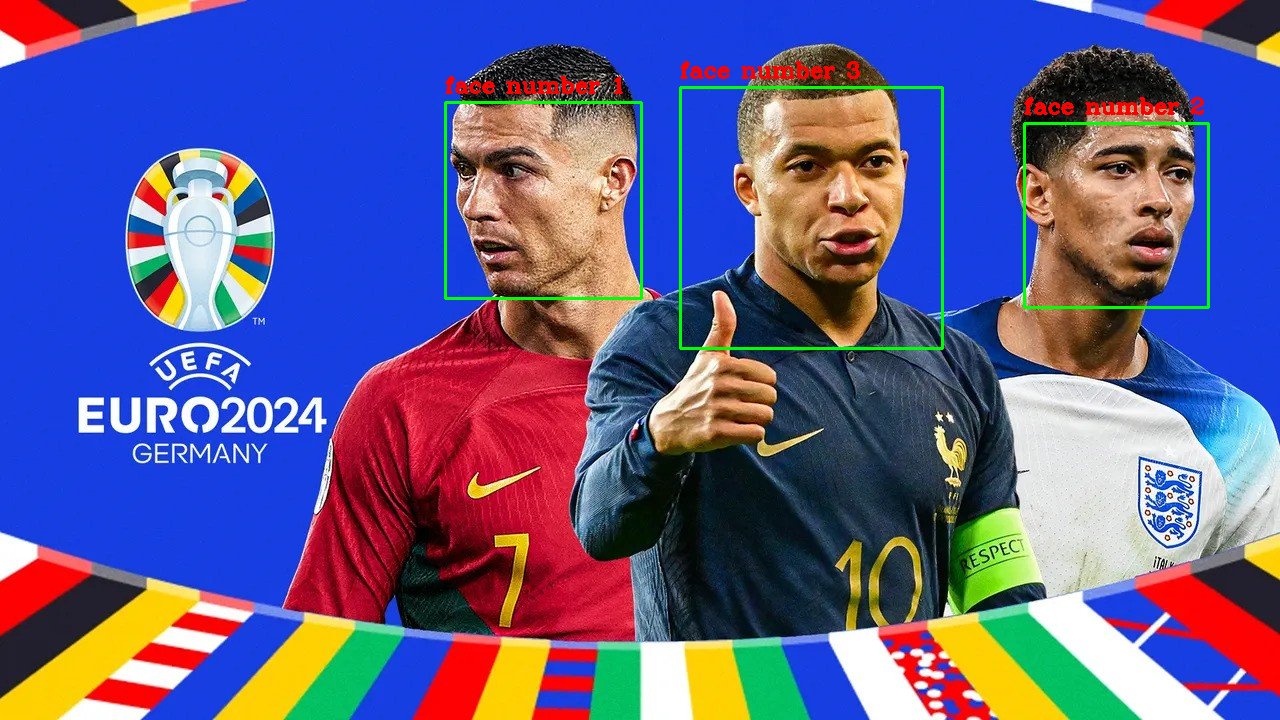

In [9]:
# Draw bounding boxes
if results.detections:
    i = 0
    for det in results.detections:
        bbox = det.location_data.relative_bounding_box
        h, w, c = image.shape

        x1 = int(bbox.xmin * w)
        y1 = int(bbox.ymin * h)
        x2 = int((bbox.xmin + bbox.width) * w)
        y2 = int((bbox.ymin + bbox.height) * h)

        cv2.rectangle(image, (x1, y1), (x2, y2), (0,255,0), 2)

        i += 1
        # Corrected cv2.putText arguments
        cv2.putText(image, 'face number ' + str(i), (x1, y1 - 10), cv2.FONT_HERSHEY_COMPLEX, 0.7, (0, 0, 255), 2)

# Show the image in Colab
from google.colab.patches import cv2_imshow
cv2_imshow(image)